# Práctica 1. Sensado y Análisis de Audio
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.

El objetivo de esta práctica es desarrollar un sistema de clasificación de actividades basado en el análisis de audio capturado en entornos domésticos reales. Se utilizarán técnicas de procesamiento de señales de audio, extracción de características y algoritmos de aprendizaje automático para identificar diferentes actividades a partir de grabaciones de audio.

## Dataset
El dataset fue creado mediante la captura de sonidos por parte de estudiantes en entornos domésticos reales para identificar 6 actividades: Baño: Bajarle al WC. Cocina: Lavar platos. Sala: Conversación. Oficina: Música de fondo. Múltiples lugares: Pasos al caminar. Clase nula: Otros sonidos. 

Cada estudiante grabó 3 audios por clase (18 en total) con una duración de 10 segundos por audio.

El formato para los nombres de los archivos es el siguiente: ID-CLASE-MUESTRA.wav

ID:= identificador del estudiante que realizó capturó el audio.
CLASE:= indica el tipo de actividad que se está realizando en el audio.
MUESTRA:= número de muestra por cada clase.

## Importación de bibliotecas

In [ ]:
import os
import re
from tqdm import tqdm

# Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Audio
import librosa
import soundfile as sf
import noisereduce as nr

## Procesamiento de los audios

In [2]:
dataset_path = './dataset'

In [3]:
dataset_df = pd.DataFrame(
    columns=[
        "file_name",
        "file_path",
        "student_id",
        "class_label",
        "sample_number",
        "treatment",
    ]
)

Cargamos los audios y guardamos sus detalles en un DataFrame de pandas.

In [4]:
rows = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-Z]+)_([A-Za-z0-9]+)_([0-9]+)\.wav", file)
            if match:
                student_id = match.group(1)
                class_label = match.group(2).lower()
                sample_number = match.group(3)

                if "test" in root.lower():
                    treatment = "test"
                else:
                    treatment = "train"
                rows.append(
                    {
                        "file_name": file,
                        "file_path": file_path,
                        "student_id": student_id,
                        "class_label": class_label,
                        "sample_number": sample_number,
                        "treatment": treatment,
                    }
                )

dataset_df = pd.concat([dataset_df, pd.DataFrame(rows)], ignore_index=True)

In [5]:
dataset_df

,file_name,file_path,student_id,class_label,sample_number,treatment
0,DISC_BANO_01.wav,./dataset\Diana Itzel\DISC_BANO_01.wav,DISC,bano,01,train
1,DISC_BANO_02.wav,./dataset\Diana Itzel\DISC_BANO_02.wav,DISC,bano,02,train
2,DISC_BANO_03.wav,./dataset\Diana Itzel\DISC_BANO_03.wav,DISC,bano,03,train
3,DISC_COCINA_01.wav,./dataset\Diana Itzel\DISC_COCINA_01.wav,DISC,cocina,01,train
4,DISC_COCINA_02.wav,./dataset\Diana Itzel\DISC_COCINA_02.wav,DISC,cocina,02,train
...,...,...,...,...,...,...
193,FZCLA_PASOS_02.wav,./dataset\Zarif León\FZCLA_PASOS_02.wav,FZCLA,pasos,02,train
194,FZCLA_PASOS_03.wav,./dataset\Zarif León\FZCLA_PASOS_03.wav,FZCLA,pasos,03,train
195,FZCLA_SALA_01.wav,./dataset\Zarif León\FZCLA_SALA_01.wav,FZCLA,sala,01,train
196,FZCLA_SALA_02.wav,./dataset\Zarif León\FZCLA_SALA_02.wav,FZCLA,sala,02,train


### Eliminación de ruido y normalización

Se aplica reducción de ruido y normalización a los audios para mejorar la calidad del sonido y facilitar el análisis posterior.

In [6]:
def denoise_normalize_audio(file_path, sr=22050):
    # Cargar audio
    audio, sr = librosa.load(file_path, sr=sr)

    # Reducción de ruido
    noise = audio[0:sr] 
    audio_denoised = nr.reduce_noise(y=audio, sr=sr, y_noise=noise)

    # Normalización
    audio_normalized = librosa.util.normalize(audio_denoised)

    return audio, audio_normalized, sr

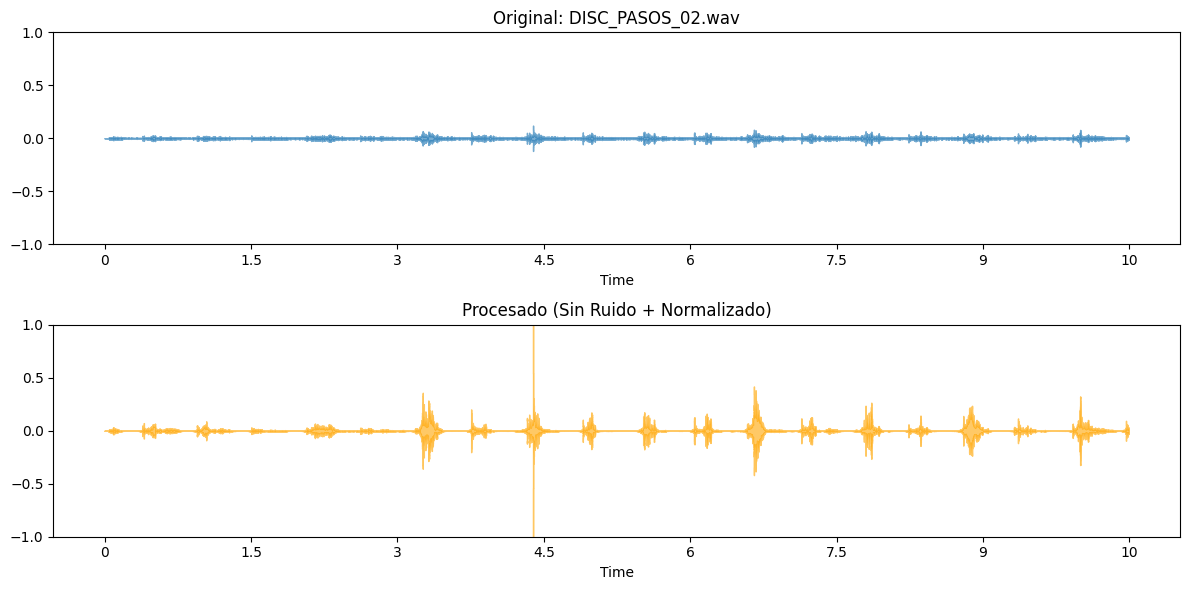

In [7]:
# Seleccionamos un archivo de ejemplo
sample_file = dataset_df.iloc[13]['file_path']

# Aplicamos la función
original, procesado, sr = denoise_normalize_audio(sample_file)

# Visualización
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(original, sr=sr, alpha=0.6)
plt.title(f'Original: {dataset_df.iloc[13]["file_name"]}')
plt.ylim(-1, 1)

plt.subplot(2, 1, 2)
librosa.display.waveshow(procesado, sr=sr, color='orange', alpha=0.6)
plt.title('Procesado (Sin Ruido + Normalizado)')
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

Aplicamos el procesamiento a todos los audios del dataset. Se guardarán los audios procesados en una carpeta separada.

In [8]:
processed_path = './processed_dataset'
os.makedirs(processed_path, exist_ok=True)

In [9]:
save_paths = []
for index, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    treatment = row['treatment']

    # Crear subdirectorio si no existe
    save_dir = os.path.join(processed_path, treatment)
    os.makedirs(save_dir, exist_ok=True)

    file_path = row['file_path']
    file_name = row['file_name']

    audio, audio_processed, sr = denoise_normalize_audio(file_path)

    save_path = os.path.join(save_dir, file_name)

    sf.write(save_path, audio_processed, sr)

    save_paths.append(save_path)

dataset_df['processed_file_path'] = save_paths

100%|██████████| 198/198 [00:24<00:00,  7.95it/s]


## Extracción y Selección de características
Se extraen las siguientes características de cada audio procesado:
- MFCCs (13 coeficientes)
- Zero-Crossing Rate (ZCR)
- Energía (RMS)

### Extracción

In [10]:
# Extracción de características
def extract_features(file_path, sr=22050, n_mfcc=13):
    # Cargar audio
    audio, sr = librosa.load(file_path, sr=sr)

    # MFCCs
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc).mean(axis=1)

    # Zero-Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=audio)
    zcr_mean = np.mean(zcr)

    # Energía (RMS)
    rms = librosa.feature.rms(y=audio)
    rms_mean = np.mean(rms)

    features = {
        'zcr': zcr_mean,
        'rms': rms_mean
    }

    for i, coef in enumerate(mfccs):
        features[f'mfcc_{i+1}'] = coef

    return features

In [11]:
features_list = []
for index, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    file_path = row['processed_file_path']

    features = extract_features(file_path)
    features['label'] = row['class_label']
    features['treatment'] = row['treatment']
    features['file_name'] = row['file_name']
    features['file_path'] = file_path

    features_list.append(features)

features_df = pd.DataFrame(features_list)
df_features = features_df[['file_name', 'file_path', 'label', 'treatment'] + [col for col in features_df.columns if col not in ['file_name', 'file_path', 'label', 'treatment']]]

df_features.head()

100%|██████████| 198/198 [00:05<00:00, 35.86it/s]


,file_name,file_path,label,treatment,zcr,rms,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,DISC_BANO_01.wav,./processed_dataset\train\DISC_BANO_01.wav,bano,train,0.210379,0.028968,-451.450226,31.853134,-5.122694,1.194075,8.400029,-0.624703,1.363322,9.449473,1.810641,-0.230205,-1.410086,1.005146,-3.272138
1,DISC_BANO_02.wav,./processed_dataset\train\DISC_BANO_02.wav,bano,train,0.215773,0.031932,-402.268311,24.979120,4.193438,8.459335,-0.712892,-1.525828,-7.739526,-8.132137,-6.525769,-0.572699,-0.448453,3.208490,-3.238113
2,DISC_BANO_03.wav,./processed_dataset\train\DISC_BANO_03.wav,bano,train,0.182699,0.020453,-474.485962,35.087517,8.589291,8.714605,-1.870407,-4.413614,-2.668115,-1.274883,-1.888022,-0.044687,-0.410286,-1.819416,-1.907745
3,DISC_COCINA_01.wav,./processed_dataset\train\DISC_COCINA_01.wav,cocina,train,0.171490,0.020071,-480.800079,47.499580,-0.354603,12.828066,-2.530189,2.880037,2.094961,2.079934,3.429186,0.831507,-2.691418,0.890973,-2.930751
4,DISC_COCINA_02.wav,./processed_dataset\train\DISC_COCINA_02.wav,cocina,train,0.188282,0.020651,-473.388519,28.094315,-0.086087,-0.024199,-4.365258,-0.642758,-3.239097,-0.456901,-3.321336,-0.931934,-1.443262,1.746244,-0.194522


In [12]:
# Guardar las características extraídas
features_save_path = './extracted_features.csv'
df_features.to_csv(features_save_path, index=False)

### Selección
Se seleccionan las características más relevantes utilizando la información mutua.

In [13]:
features_df = pd.read_csv(features_save_path)

features_train_df = features_df[features_df['treatment'] == 'train'] # Excluir datos de prueba

In [14]:
X_train = features_train_df.drop(columns=['file_name', 'file_path', 'label', 'treatment'])
y_train = features_train_df['label']

# Obtenemos la importancia de las características
features_importance = mutual_info_classif(X_train, y_train, discrete_features=False, random_state=42)

feat_imp_df = pd.DataFrame(features_importance, X_train.columns)

feat_imp_df_sorted = feat_imp_df.sort_values(by=0, ascending=False)

display(feat_imp_df_sorted)

,0
mfcc_1,0.402051
rms,0.332215
mfcc_8,0.305261
mfcc_2,0.288439
mfcc_12,0.277102
mfcc_10,0.241351
mfcc_3,0.240148
mfcc_6,0.237564
mfcc_5,0.218367
mfcc_7,0.213752


De acuerdo con los resultados obtenidos, se descarta la característica mfcc_13 la cual obtuvo valor de importancia menor a 0.1.

In [15]:
selected_features = feat_imp_df_sorted[feat_imp_df_sorted[0] >= 0.1].index.tolist()

print(f"Características seleccionadas ({len(selected_features)}): {selected_features}")

Características seleccionadas (14): ['mfcc_1', 'rms', 'mfcc_8', 'mfcc_2', 'mfcc_12', 'mfcc_10', 'mfcc_3', 'mfcc_6', 'mfcc_5', 'mfcc_7', 'mfcc_11', 'mfcc_9', 'mfcc_4', 'zcr']


## Construcción y evaluación de modelos

### Preparar conjuntos de datos de entrenamiento y prueba
Se dividen los datos en los conjuntos de entrenamiento y prueba mencionados anteriormente.

In [16]:
df_train = features_df[features_df['treatment'] == 'train']
df_test = features_df[features_df['treatment'] == 'test']

X_train = df_train[selected_features]
y_train = df_train['label']

X_test = df_test[selected_features]
y_test = df_test['label']

# Codificar etiquetas
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [17]:
classes = label_encoder.classes_
print(f"Clases: {classes}")

Clases: ['bano' 'cocina' 'nula' 'oficina' 'pasos' 'sala']


### Definir modelos y pipeline
Se utilizarán los modelos: Random Forest, SVM, KNN, Naive Bayes y Gradient Boosting. Se crea un pipeline para estandarizar las características y entrenar los modelos. 

Además, se añade una validación extra para comparar el rendimiento con los datos de entrenamiento respecto a los datos de prueba.

In [18]:
# Se crea un objeto StratifiedKFold para dividir los datos en folds de manera estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
# Modelos
models = {
    "Random Forest": Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),

    "SVM": Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
    ]),

    "k-NN": Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes": Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', GaussianNB())
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

### Entrenamiento y evaluación


Random Forest
F1-Score Macro (Cross-Validation): 0.6824
F1-Score Macro: 0.4556
Accuracy: 0.5000

Reporte de Clasificación:
              precision    recall  f1-score   support

        bano       1.00      0.33      0.50         3
      cocina       0.50      1.00      0.67         3
        nula       0.50      0.33      0.40         3
     oficina       0.00      0.00      0.00         3
       pasos       0.50      1.00      0.67         3
        sala       1.00      0.33      0.50         3

    accuracy                           0.50        18
   macro avg       0.58      0.50      0.46        18
weighted avg       0.58      0.50      0.46        18



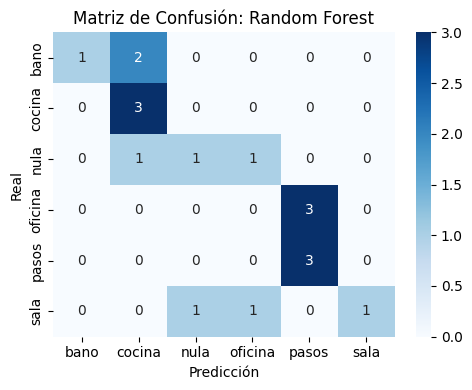


SVM
F1-Score Macro (Cross-Validation): 0.6659
F1-Score Macro: 0.2778
Accuracy: 0.3889

Reporte de Clasificación:
              precision    recall  f1-score   support

        bano       0.00      0.00      0.00         3
      cocina       0.50      1.00      0.67         3
        nula       0.50      0.33      0.40         3
     oficina       0.00      0.00      0.00         3
       pasos       0.43      1.00      0.60         3
        sala       0.00      0.00      0.00         3

    accuracy                           0.39        18
   macro avg       0.24      0.39      0.28        18
weighted avg       0.24      0.39      0.28        18



c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


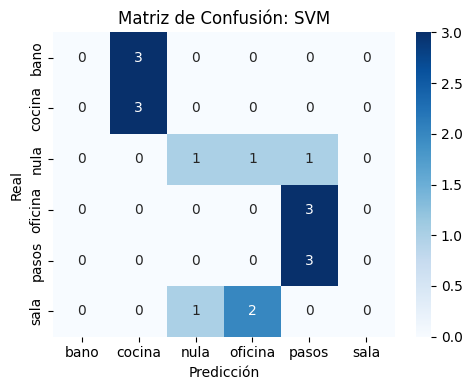


k-NN
F1-Score Macro (Cross-Validation): 0.4621
F1-Score Macro: 0.3611
Accuracy: 0.4444

Reporte de Clasificación:
              precision    recall  f1-score   support

        bano       1.00      0.33      0.50         3
      cocina       0.50      1.00      0.67         3
        nula       0.00      0.00      0.00         3
     oficina       0.00      0.00      0.00         3
       pasos       0.43      1.00      0.60         3
        sala       0.50      0.33      0.40         3

    accuracy                           0.44        18
   macro avg       0.40      0.44      0.36        18
weighted avg       0.40      0.44      0.36        18



c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


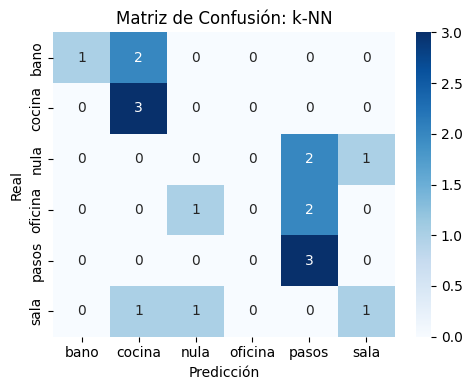


Naive Bayes
F1-Score Macro (Cross-Validation): 0.6142
F1-Score Macro: 0.3373
Accuracy: 0.3889

Reporte de Clasificación:
              precision    recall  f1-score   support

        bano       0.00      0.00      0.00         3
      cocina       0.50      1.00      0.67         3
        nula       0.25      0.33      0.29         3
     oficina       0.00      0.00      0.00         3
       pasos       0.50      0.67      0.57         3
        sala       1.00      0.33      0.50         3

    accuracy                           0.39        18
   macro avg       0.38      0.39      0.34        18
weighted avg       0.38      0.39      0.34        18



c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Zarif\.conda\envs\master\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


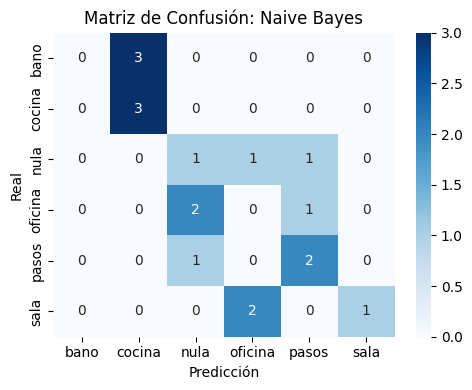


Gradient Boosting
F1-Score Macro (Cross-Validation): 0.6150
F1-Score Macro: 0.4325
Accuracy: 0.4444

Reporte de Clasificación:
              precision    recall  f1-score   support

        bano       0.67      0.67      0.67         3
      cocina       0.75      1.00      0.86         3
        nula       0.00      0.00      0.00         3
     oficina       0.00      0.00      0.00         3
       pasos       0.50      0.67      0.57         3
        sala       1.00      0.33      0.50         3

    accuracy                           0.44        18
   macro avg       0.49      0.44      0.43        18
weighted avg       0.49      0.44      0.43        18



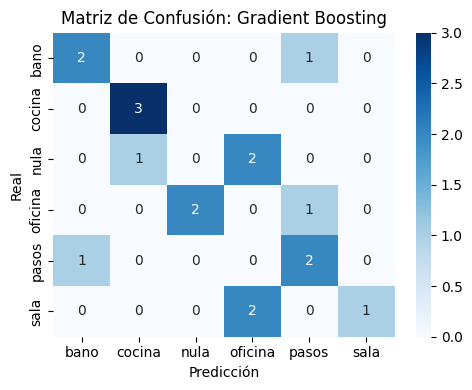

In [20]:
results = []
for i, (name, model) in enumerate(models.items()):
    print("\n======================")
    print(f"{name}")

    # Validación cruzada
    cv_scores = cross_val_score(model, X_train, y_train_encoded, cv=cv, scoring='f1_macro')
    mean_cv_score = cv_scores.mean()

    # Entrenar el modelo con todos los datos de entrenamiento
    model.fit(X_train, y_train_encoded)

    # Predecir en el conjunto de prueba
    y_pred = model.predict(X_test)
    
    # Evaluar
    test_f1 = f1_score(y_test_encoded, y_pred, average='macro')
    accuracy = accuracy_score(y_test_encoded, y_pred)
    print(f"F1-Score Macro (Cross-Validation): {mean_cv_score:.4f}")
    print(f"F1-Score Macro: {test_f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    classification_report_str = classification_report(y_test_encoded, y_pred, target_names=classes)
    print("\nReporte de Clasificación:")
    print(classification_report_str)
    # Guardar resultados
    results.append({'Model': name, 'F1-Score Macro (Cross-Validation)': mean_cv_score, 'F1-Score Macro': test_f1, 'Accuracy': accuracy, 'Report': classification_report_str})

    # Matriz de Confusión
    cm = confusion_matrix(y_test_encoded, y_pred)
    
    # Graficar matriz de confusión
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión: {name}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

El mejor modelo es Random Forest, con un F1-score de 0.455556 en el conjunto de prueba.

In [21]:
results_df = pd.DataFrame(results)
best_model = results_df.loc[results_df['F1-Score Macro'].idxmax()]
print("Mejor modelo:")
print(best_model)

Mejor modelo:
Model                                                                    Random Forest
F1-Score Macro (Cross-Validation)                                             0.682411
F1-Score Macro                                                                0.455556
Accuracy                                                                           0.5
Report                                             precision    recall  f1-score   ...
Name: 0, dtype: object


## Análisis de resultados y Conclusiones

Prácticamente, todos los modelos tuviero un desempeño pobre, con F1-scores por debajo de 0.5 en el conjunto de prueba. Random Forest fue el mejor modelo (F1-score: 0.455556), pero aún así su desempeño es limitado.

Esto puede deberse a que las características extraídas pueden no ser suficientemente discriminativas para las clases de actividades consideradas, o que el dataset es demasiado pequeño y ruidoso para entrenar modelos efectivos. Las clases mejor reconocidas entre los modelos fueron "Cocina" y "Pasos", mientras que "Oficina" no fue reconocida en ningún modelo.

Sin embargo, es importante mencionar que el conjunto de prueba fue incorrectamente etiquetado, en específico, la totalidad de la clase 'Bano' no contenía audios de dicha clase, y muestras de otras clases también estaban mal etiquetadas. Debido a esto, se decidió obtener el F1-Score de una validación cruzada con 5 folds en el conjunto de entrenamiento, que resultó ser de 0.682411 para el modelo de Random Forest el cual, si bien no es elevado, es considerablemente mejor que el obtenido en el conjunto de prueba.